In [1]:
SEED = 42

In [2]:
import torch
from torch import nn
import random
import numpy as np

# prima di tutto, dobbiamo impostare un seed per garantire la riproducibilità dei risultati. Questo è particolarmente importante quando si lavora con modelli di machine learning, poiché molte operazioni sono stocastiche.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
set_seed(SEED)

# Poi dobbiamo settare il device su cui vogliamo eseguire il modello. Se abbiamo una GPU disponibile, useremo quella, altrimenti useremo la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
    

Using device: cpu


In [3]:
# Prepariamo il dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from torch.utils.data import DataLoader, TensorDataset

iris_dataset = load_iris()
X, y = iris_dataset.data, iris_dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

steps = [
    ('scaler', StandardScaler()),
    ('mean_imputer', SimpleImputer(strategy='mean'))
]
pipe = Pipeline(steps)
X_train = pipe.fit_transform(X_train, y_train)
X_test = pipe.transform(X_test)







In [4]:
# Conversione in tensori perchè PyTorch lavora con tensori. Inoltre, dobbiamo assicurarci che i dati siano sullo stesso device del modello.
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)


In [5]:
# Creazione del DataLoader
# A cosa serve il DataLoader? Serve a gestire il batch processing dei dati, a mescolare i dati e a fornire un'interfaccia più semplice per iterare sui dati durante l'addestramento del modello.
# Il Batch Processing è una tecnica che consiste nel dividere il dataset in piccoli batch di dati, invece di utilizzare l'intero dataset per ogni aggiornamento dei pesi del modello. Questo permette di ridurre il consumo di memoria e di accelerare l'addestramento del modello.


train_loader = TensorDataset(X_train_tensor, y_train_tensor) # TensorDataset è una classe di PyTorch che permette di creare un dataset a partire da tensori. In questo caso, stiamo creando un dataset a partire dai tensori X_train_tensor e y_train_tensor.
# Si potrebbe usare solo X_train_tensor e y_train_tensor, ma TensorDataset ci permette di creare un dataset più facilmente e di gestire meglio i dati durante l'addestramento del modello.
test_loader = TensorDataset(X_test_tensor, y_test_tensor)

print(train_loader)
# Batch size: ad esempio se batch_size = 16, significa che ogni volta che il modello aggiorna i pesi, lo fa utilizzando 16 campioni del dataset. Questo permette di ridurre il consumo di memoria e di accelerare l'addestramento del modello.
train_loader = DataLoader(train_loader, batch_size=16, shuffle=True)
test_loader = DataLoader(test_loader, batch_size=16, shuffle=False)
print(train_loader)




In [6]:
# Costruiamo la rete:
# Loss Function = CrossEntropyLoss: è una funzione di perdita comunemente usata per problemi di classificazione multi-classe. Calcola la differenza tra le probabilità previste dal modello e le etichette reali, penalizzando maggiormente le previsioni errate.
# Optimizer = Adam: è un algoritmo di ottimizzazione che combina i vantaggi di due altri algoritmi di ottimizzazione: AdaGrad e RMSProp. È particolarmente efficace per problemi di ottimizzazione non convessi e per grandi dataset.

import torch.nn.functional as F

class IrisNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim): # Nel nostro caso input_dim = 4 (numero di feature del dataset Iris), hidden_dim = 10 (numero di neuroni nel layer nascosto), output_dim = 3 (numero di classi del dataset Iris).
        super(IrisNet, self).__init__() # cosa fa questa riga? Chiama il costruttore della classe base nn.Module, che è necessario per inizializzare correttamente il modello. Senza questa riga, il modello non funzionerebbe correttamente.
        
        
        self.fc1 = nn.Linear(input_dim, hidden_dim) # Crea un layer lineare (fully connected) che prende in input input_dim e produce hidden_dim output. In questo caso, input_dim = 4 (numero di feature del dataset Iris), hidden_dim = 10 (numero di neuroni nel layer nascosto).
        self.dropout = nn.Dropout(p=0.1) # Aggiunge un layer di dropout con probabilità di 0.1. Il dropout è una tecnica di regolarizzazione che consiste nel "spegnere" casualmente alcuni neuroni durante l'addestramento, per evitare l'overfitting.
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) # Crea un layer lineare (fully connected) che prende in input hidden_dim e produce output_dim output. In questo caso, hidden_dim = 10 (numero di neuroni nel layer nascosto), output_dim = 3 (numero di classi del dataset Iris).
        
        self.fc3 = nn.Linear(hidden_dim, output_dim) # Crea un layer lineare (fully connected) che prende in input hidden_dim e produce output_dim output. In questo caso, hidden_dim = 10 (numero di neuroni nel layer nascosto), output_dim = 3 (numero di classi del dataset Iris).
    def forward(self, x): # Definisce il passaggio in avanti del modello. In questo caso, il passaggio in avanti consiste nel passare l'input x attraverso i due layer lineari e applicare la funzione di attivazione ReLU tra i due layer.
        x = F.relu(self.fc1(x)) # Applica la funzione di attivazione ReLU al primo layer lineare. La funzione ReLU (Rectified Linear Unit) è una funzione di attivazione che restituisce 0 per input negativi e l'input stesso per input positivi. È comunemente usata nelle reti neurali perché aiuta a prevenire il problema del vanishing gradient.
        x = self.dropout(x) # Applica il layer di dropout all'output del primo layer.
        
        x = F.relu(self.fc2(x)) # Passa l'output del primo layer attraverso il secondo layer lineare.
        x = self.fc3(x) # Passa l'output del secondo layer attraverso il terzo layer lineare.
        return x # Restituisce l'output finale del modello.
    
model = IrisNet(input_dim=4, hidden_dim=10, output_dim=3).to(device) # Crea un'istanza del modello IrisNet e la sposta sul device (CPU o GPU) che abbiamo scelto in precedenza.


num_params = 0
for x in model.parameters():
    num_params += len(torch.flatten(x))
print(f"number of parameters: {num_params: }")


number of parameters:  193


In [7]:
from torch import optim

criterion = nn.CrossEntropyLoss() # Crea un'istanza della funzione di perdita CrossEntropyLoss. Questa funzione di perdita è comunemente usata per problemi di classificazione multi-classe.
optimizer = optim.Adam(model.parameters(), lr=0.001) # Crea un'istanza dell'ottimizzatore Adam. Questo ottimizzatore aggiorna i pesi del modello durante l'addestramento, cercando di minimizzare la funzione di perdita. Il learning rate (lr) è un iperparametro che controlla la dimensione dei passi che l'ottimizzatore fa nella direzione del gradiente.



In [8]:
EPOCHES = 200

for epoch in range(EPOCHES):
    model.train()
    epoch_loss = 0.0
    running_accuracy = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        # FOrward pass
        predictions = model(data)
        correct = torch.sum(target == torch.argmax(predictions, dim=1)).item() # Calcola il numero di predizioni corrette in questo batch. torch.argmax(predictions, dim=1) restituisce l'indice della classe con la probabilità più alta per ogni campione nel batch.
        running_accuracy += correct / data.size(0) # Calcola l'accuratezza di questo batch. data.size(0) restituisce il numero di campioni in questo batch.
        loss = criterion(predictions, target)
        
        # Azzera i gradienti. Questo passo è fondamentale, perché PyTorch accumula i gradienti per default. Se non azzeriamo i gradienti, i gradienti calcolati in questo batch si sommeranno a quelli calcolati nei batch precedenti, portando a un aggiornamento dei pesi errato.
        optimizer.zero_grad()
        
        # Backward pass
        loss.backward() # Calcola i gradienti della funzione di perdita rispetto ai pesi del modello. Questo passo è fondamentale per l'ottimizzazione dei pesi del modello.
        
        # Aggiorna i pesi del modello
        optimizer.step() # Aggiorna i pesi del modello utilizzando i gradienti calcolati nel passo precedente. Questo passo è fondamentale per l'ottimizzazione dei pesi del modello.
        
        epoch_loss += loss.item() # Aggiunge il valore della perdita di questo batch alla perdita totale dell'epoca. loss.item() restituisce il valore della perdita come un numero float, invece di un tensore.
        if (batch_idx) % 5 == 4:
            avg_acc_across_batches = (running_accuracy / 500)*100
            print (f'\tBatch {batch_idx + 1}, Acc {avg_acc_across_batches :.1f}%')

            running_loss = .0
            running_accuracy =.0
        
    if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHES} | Loss: {epoch_loss/len(train_loader):.4f}")
        
    


	Batch 5, Acc 0.3%
	Batch 5, Acc 0.3%
	Batch 5, Acc 0.4%
	Batch 5, Acc 0.3%
	Batch 5, Acc 0.3%
	Batch 5, Acc 0.3%
	Batch 5, Acc 0.3%
	Batch 5, Acc 0.3%
	Batch 5, Acc 0.3%
	Batch 5, Acc 0.4%
Epoch 10/200 | Loss: 0.9905
	Batch 5, Acc 0.6%
	Batch 5, Acc 0.6%
	Batch 5, Acc 0.6%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.6%
	Batch 5, Acc 0.6%
Epoch 20/200 | Loss: 0.6958
	Batch 5, Acc 0.6%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.6%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.6%
Epoch 30/200 | Loss: 0.4952
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.7%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.9%
	Batch 5, Acc 0.9%
Epoch 40/200 | Loss: 0.4317
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.9%
	Batch 5, Acc 0.8%
	Batch 5, Acc 0.8%
	Batch 5, Acc 

In [9]:
# Ora passiamo alla valutazione del modello. Per farlo dobbiamo togliere il dropout e mettere il modello in modalità di valutazione. Questo è importante perché il dropout è una tecnica di regolarizzazione che viene utilizzata solo durante l'addestramento del modello. Durante la valutazione, vogliamo che tutti i neuroni siano attivi, quindi dobbiamo disattivare il dropout.

model.eval() # Mette il modello in modalità di valutazione. Questo disattiva il dropout e altre tecniche di regolarizzazione che vengono utilizzate solo durante l'addestramento del modello.

correct = 0
total = 0

all_predictions = []
all_targets = []

with torch.no_grad(): # Disabilita il calcolo dei gradienti. Questo è importante durante la valutazione del modello, perché non vogliamo aggiornare i pesi del modello durante la valutazione.
    for data, target in test_loader:
        predictions = model(data)
        _, predicted = torch.max(predictions.data, 1) # Restituisce l'indice della classe con la probabilità più alta. Questo è il nostro "voto" del modello per la classe dell'input.
        all_predictions.extend(predicted.cpu().numpy()) # Aggiunge il numero di campioni in questo batch al totale dei campioni.
        all_targets.extend(target.cpu().numpy()) # Aggiunge il numero di campioni in questo batch al totale dei campioni.
        correct += (predicted == target).sum().item() # Aggiunge il numero di predizioni corrette in questo batch al totale delle predizioni corrette.

from sklearn.metrics import classification_report, confusion_matrix
# 1. Matrice di Confusione
print("=== Confusion Matrix ===")
print(confusion_matrix(all_targets, all_predictions))
print("\n")

# 2. Precision, Recall e F1-Score per ogni classe
print("=== Classification Report ===")
print(classification_report(all_targets, all_predictions, target_names=['Setosa', 'Versicolor', 'Virginica']))


=== Confusion Matrix ===
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


=== Classification Report ===
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# GAN
Una GAN (Generative Adversarial Network) si basa su due reti neurali in competizione diretta all'interno di un gioco a somma zero:

Il Generatore (G): Riceve in input un vettore di rumore casuale (campionato da uno spazio latente) e applica delle trasformazioni per generare dati sintetici (es. immagini) il più realistici possibile. Il suo unico obiettivo è produrre output che il Discriminatore classifichi come reali.

Il Discriminatore (D): Funziona come un classificatore binario. Riceve in input un mix di dati reali (dal dataset) e dati falsi (creati da G). Il suo obiettivo è imparare a distinguere correttamente i dati genuini dalle falsificazioni (1 per reale, 0 per falso).

L'addestramento procede in parallelo: mentre D diventa più bravo a scovare i falsi, G è costretto a generare falsi sempre più sofisticati per continuare a ingannare D.

In [10]:
import torch
import numpy as np
import random


SEED = 42
BATCH_SIZE = 64

def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
set_seed(SEED)
    




In [11]:
# Dataset MNIST ovvero cifre scritte a mano in scala di grigi
from torchvision import datasets # datasets contiene i dataset come il MNIST, mentre transforms contiene le trasformazioni che possiamo applicare ai dati, come la normalizzazione o la conversione in tensori.
from torchvision.transforms import v2 # transforms contiene le trasformazioni che possiamo applicare ai dati, come la normalizzazione o la conversione in tensori. In questo caso, stiamo importando la versione 2 delle trasformazioni, che è più recente e ha alcune funzionalità aggiuntive rispetto alla versione 1.
# ToTensor: solitamente le immagini sono altezzaxlarghezzaxcanali con valori pixel tra 0 e 255. ToTensor converte le immagini in tensori con valori tra 0 e 1, normalizzando i valori dei pixel. Inoltre, ToTensor cambia l'ordine delle dimensioni dell'immagine da altezza x larghezza x canali a canali x altezza x larghezza, che è l'ordine richiesto da PyTorch.
# Normalize: normalizza i valori dei pixel dell'immagine. In questo caso, stiamo normalizzando i valori dei pixel in modo che abbiano una media di 0.5 e una deviazione standard di 0.5. 
## Infatti il generatore di una GAN finisce con tanh che sputa valori tra -1 e 1 e li da in pasto al Discriminatore. Quindi tutto è più stabile

transform = v2.Compose([
    v2.ToTensor(),
    v2.Normalize(mean=[0.5], std=[0.5])]   
)
mnist_dataset_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform) # Crea un'istanza del dataset MNIST. root è la directory in cui verranno salvati i dati, train indica se vogliamo il dataset di addestramento o di test, download indica se vogliamo scaricare i dati se non sono già presenti nella directory root, transform indica le trasformazioni da applicare ai dati. In questo caso, stiamo convertendo le immagini in tensori.


mnist_dataset_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform) # Crea un'istanza del dataset MNIST per il test.


c:\dev\arti\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [12]:
# DataLoader: è una classe di PyTorch che permette di iterare sui dati in batch. In questo caso, stiamo creando un DataLoader per il dataset di addestramento e uno per il dataset di test. batch_size indica il numero di campioni in ogni batch, shuffle indica se vogliamo mescolare i dati ad ogni epoca, num_workers indica il numero di processi da utilizzare per caricare i dati (0 significa che i dati verranno caricati nel processo principale).
from torch.utils.data import DataLoader
train_loader = DataLoader(
    dataset = mnist_dataset_train,
    shuffle = True,
    batch_size = BATCH_SIZE,
    num_workers = 2
)


--- DATI ORIGINALI ---
Shape array originale: (28, 28)
Valore Min / Max originale: 0 / 255

Porzione centrale dell'immagine (valori 0-255):
[[  1 154 253  90   0]
 [  0 139 253 190   2]
 [  0  11 190 253  70]
 [  0   0  35 241 225]
 [  0   0   0  81 240]]

--- DATI TRASFORMATI ---
Shape del tensore: torch.Size([1, 28, 28])
Valore Min / Max trasformato: -1.0000 / 1.0000


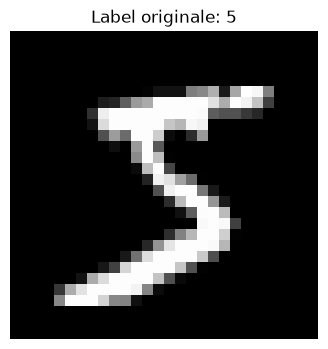

In [13]:
import matplotlib.pyplot as plt

# Istanziamo un dataset raw senza le trasformazioni per vedere i dati originali
dataset_raw = datasets.MNIST(root='./data', train=True, download=True)
raw_image, label = dataset_raw[0] # Restituisce un oggetto PIL Image

# 2. Vediamo l'array di pixel originale
raw_array = np.array(raw_image)
print("--- DATI ORIGINALI ---")
print(f"Shape array originale: {raw_array.shape}") # (28, 28)
print(f"Valore Min / Max originale: {raw_array.min()} / {raw_array.max()}")
print("\nPorzione centrale dell'immagine (valori 0-255):")
print(raw_array[10:15, 10:15]) # Stampiamo un crop 5x5 centrale

# 3. Vediamo il tensore generato dalle trasformazioni
transformed_tensor, _ = mnist_dataset_train[0]
print("\n--- DATI TRASFORMATI ---")
print(f"Shape del tensore: {transformed_tensor.shape}") # (1, 28, 28)
print(f"Valore Min / Max trasformato: {transformed_tensor.min():.4f} / {transformed_tensor.max():.4f}")

# 1. Visualizziamo l'immagine
plt.figure(figsize=(4, 4))
plt.title(f"Label originale: {label}")
# IMPORTANTE: matplotlib si aspetta immagini (H, W) per il bianco e nero. 
# Il nostro tensore è (1, 28, 28). Usiamo squeeze() per rimuovere la dimensione di grandezza 1.
plt.imshow(transformed_tensor.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [14]:
train_loader

In [15]:
from torch import optim
from torch import nn
import torch.nn.functional as F



class DiscriminatorNet(nn.Module):
    def __init__(self, input_dim=28*28, output_dim=1):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        
        #
        
        self.fc1 = nn.Linear(input_dim, 512)
        self.dropout1 = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, output_dim)
        
    def forward(self, x):
        x = x.view(-1, self.input_dim)
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout1(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.fc3(x)
        
        return x
        
        
    
        

class GeneratorNet(nn.Module):
    def __init__(self, input_dim = 100, output_dim=28*28):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, output_dim)
        
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        
        x = x.view(-1, 1, 28, 28)
        
        return x
        
        
        
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")    
Generator = GeneratorNet().to(device)
Discriminator = DiscriminatorNet().to(device)


In [16]:
criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(Generator.parameters(), betas=(0.5, 0.999), lr=0.0002)
optimizer_D = optim.Adam(Discriminator.parameters(), betas=(0.5, 0.999), lr=0.0002)

In [ ]:
EPOCHES = 100
Z_DIM = 100
fixed_noise = torch.randn(16, Z_DIM).to(device)
losses_D, losses_G = [], []
for epoch in range(EPOCHES):
    for batch_idx, (real_images, target) in enumerate(train_loader):
        # DIscriminator
        optimizer_D.zero_grad()
        real_images = real_images.to(device)
        b_size = real_images.size(0)
        
        real_labels = torch.ones(b_size, 1).to(device)
        
        predictions_real = Discriminator(real_images)
        
        loss_D_real = criterion(predictions_real, real_labels)
        
        
        z = torch.randn(b_size, 100).to(device)
        
        fake_images = Generator(z)
        
        fake_labels = torch.zeros(b_size, 1).to(device)
        
        # Presta attenzione al detach(): stacca fake_images dal grafo del Generatore. Qui Vogliamo che impari solo D. Senza detach() il backword di D scorrerebbe fino a G, alternadone i pesi
        predictions_fake = Discriminator(fake_images.detach())
        
        loss_D_fake = criterion(predictions_fake, fake_labels)
        
        loss_D = loss_D_real + loss_D_fake
        
        loss_D.backward()
        
        optimizer_D.step()
        
        
        # Gnerator
        optimizer_G.zero_grad()
        
        # Togliamo il detach così possiamo modificare i pesi del Generatore
        predictions_fake_for_G = Discriminator(fake_images)
        
        
        loss_G = criterion(predictions_fake_for_G, real_labels)
        loss_G.backward()
        optimizer_G.step()
        
        
        losses_D.append(loss_D)
        losses_G.append(loss_G)
        
    if (epoch +1) % 3 == 0 or epoch == 0:
        print(f"EPOCH: {epoch +1}\n\tLOSS DISCRIMINATOR: {loss_D} | LOSS GENERATOR {loss_G}")


In [ ]:
Generator.eval() # Mettiamo G in modalità valutazione (disabilita Dropout/BatchNorm se presenti)
with torch.no_grad(): # Disabilitiamo il calcolo dei gradienti per risparmiare memoria
    generated_imgs = Generator(fixed_noise).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Immagini Generate", fontsize=16)
plt.tight_layout()
plt.show()